In [2]:
import os
import pandas as pd
from pathlib import Path

def analyze_art_dataset(root_path):
    root = Path(root_path)
    report = []
    
    print(f"--- Analyzing Dataset Structure at: {root} ---")
    
    # 1. Map Directory Structure
    for path, subdirs, files in os.walk(root):
        level = path.replace(str(root), '').count(os.sep)
        indent = ' ' * 4 * (level)
        folder_name = os.path.basename(path)
        report.append(f"{indent}{folder_name}/ ({len(files)} files)")

    # 2. Analyze CSV Metadata
    csv_files = list(root.glob("*.csv"))
    print(f"\nFound {len(csv_files)} metadata files.")
    
    metadata_summary = {}
    for csv_p in csv_files:
        try:
            df = pd.read_csv(csv_p, nrows=5) # Load sample to check columns
            metadata_summary[csv_p.name] = {
                "columns": df.columns.tolist(),
                "sample_count": sum(1 for _ in open(csv_p)) - 1
            }
        except Exception as e:
            print(f"Could not read {csv_p.name}: {e}")

    # 3. Print Findings
    print("\n--- Folder Tree ---")
    print("\n".join(report[:20])) # Showing first 20 for brevity
    
    print("\n--- CSV Metadata Details ---")
    for name, info in metadata_summary.items():
        print(f"\nFile: {name}")
        print(f"  - Approximate Rows: {info['sample_count']}")
        print(f"  - Key Columns: {info['columns']}")

    return metadata_summary

# Run the analysis
base_dir = r"C:\Users\Debabrata\Downloads\ART"
metadata = analyze_art_dataset(base_dir)

--- Analyzing Dataset Structure at: C:\Users\Debabrata\Downloads\ART ---

Found 17 metadata files.

--- Folder Tree ---
ART/ (17 files)

--- CSV Metadata Details ---

File: alternative_identifiers.csv
  - Approximate Rows: 210325
  - Key Columns: ['uuid', 'idschemelabel', 'identifier']

File: constituents.csv
  - Approximate Rows: 27764
  - Key Columns: ['constituentid', 'ulanid', 'preferreddisplayname', 'forwarddisplayname', 'lastname', 'displaydate', 'artistofngaobject', 'beginyear', 'endyear', 'visualbrowsertimespan', 'nationality', 'visualbrowsernationality', 'constituenttype', 'wikidataid']

File: constituents_altnames.csv
  - Approximate Rows: 35078
  - Key Columns: ['altnameid', 'constituentid', 'lastname', 'displayname', 'forwarddisplayname', 'nametype']

File: locations.csv
  - Approximate Rows: 1127
  - Key Columns: ['locationid', 'site', 'room', 'publicaccess', 'description', 'unitposition']

File: media_items.csv
  - Approximate Rows: 8254
  - Key Columns: ['mediaid', 'medi

In [5]:
import pandas as pd

# Load files
base_path = r"C:\Users\Debabrata\Downloads\ART\\"
objects = pd.read_csv(base_path + "objects.csv", low_memory=False)
images = pd.read_csv(base_path + "published_images.csv")

# 1. Targeted Filter based on your diagnostic results
mask = (
    (objects['subclassification'] == 'Historical Portrait') | 
    (objects['subclassification'] == 'Bust') |
    (objects['title'].str.contains('Portrait', na=False, case=False))
)

portraits = objects[mask]

# 2. Join with images to get the IIIF URLs
portrait_data = pd.merge(
    portraits[['objectid', 'title', 'attribution', 'subclassification']], 
    images[['depictstmsobjectid', 'iiifurl', 'uuid']], 
    left_on='objectid', 
    right_on='depictstmsobjectid'
)

print(f"Total Portrait Images Found: {len(portrait_data)}")
print(portrait_data[['title', 'subclassification']].head(10))

# Save for the next stage
portrait_data.to_csv("portrait_metadata_final.csv", index=False)

Total Portrait Images Found: 5477
                             title subclassification
0                Portrait of a Man               NaN
1       Profile Portrait of a Lady               NaN
2          Portrait of a Young Man               NaN
3  Portrait of a Man with an Arrow               NaN
4          Portrait of a Gentleman               NaN
5          Portrait of a Young Man               NaN
6               A Young Noblewoman              Bust
7               A Young Noblewoman              Bust
8                        La France              Bust
9                Portrait of a Man               NaN


In [6]:
import os
import requests
from concurrent.futures import ThreadPoolExecutor

def download_image(row):
    # Constructing a valid IIIF URL for a 512px wide image
    # Format: [base_url]/full/[width],/0/default.jpg
    img_url = f"{row['iiifurl']}/full/512,/0/default.jpg"
    save_path = os.path.join("portraits", f"{row['uuid']}.jpg")
    
    if not os.path.exists(save_path):
        try:
            response = requests.get(img_url, timeout=10)
            if response.status_code == 200:
                with open(save_path, 'wb') as f:
                    f.write(response.content)
        except:
            pass

# Create folder
os.makedirs("portraits", exist_ok=True)

# Use 10 threads to download the first 1000 images quickly
print("Starting download...")
with ThreadPoolExecutor(max_workers=10) as executor:
    executor.map(download_image, portrait_data.to_dict('records')[:1000])
print("Download complete.")

Starting download...
Download complete.


In [4]:
# Check the actual unique values to see how portraits are labeled
print("Top 20 Classifications in the dataset:")
print(objects['classification'].value_counts().head(20))

# Check subclassification as well, as 'Portrait' might be there
if 'subclassification' in objects.columns:
    print("\nTop 20 Sub-classifications:")
    print(objects['subclassification'].value_counts().head(20))

Top 20 Classifications in the dataset:
classification
Print                       64851
Photograph                  21602
Drawing                     18299
Index of American Design    18259
Portfolio                    7522
Sculpture                    4688
Painting                     4430
Volume                       3276
Decorative Art                747
Technical Material            366
Time-Based Media Art           57
Name: count, dtype: int64

Top 20 Sub-classifications:
subclassification
Drawing                 18557
Print                   10661
Contact Sheet            2967
Historical Portrait      2388
Medal/Medallion          2022
Work Print               1336
Archival                 1247
Plaquette                 651
Ceramic                   450
Small Bronze              331
Bust                      188
Photograph                187
Multiple                  139
Statuette                 126
Playing Card              126
Printmaking Matrices      112
Relief             

In [8]:
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to c:\users\debabrata\appdata\local\temp\pip-req-build-3it2s1nn
  Resolved https://github.com/openai/CLIP.git to commit ded190a052fdf4585bd685cee5bc96e0310d2c93
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369633 sha256=50562d143e7227566bb2f961e6917252fe744ef95de45dbe0199c5df50d1d288
  Stored in directory: C:\Users\Debabrata\AppData\Local\Temp\pip-ephem-wheel-cache-36a83cfx\wheels\3f\7c\a4\9b490845988bf7a4db33674d52f709f088f64392063872eb9a
Successfully built clip


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\Debabrata\AppData\Local\Temp\pip-req-build-3it2s1nn'
  DEPRECATION: Building 'clip' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'clip'. Discussion can be found at https://github.com/pypa/pip/issues/6334


In [9]:
!pip install ftfy regex tqdm

In [10]:
import torch
import clip
from PIL import Image
import os
import glob

# 1. Load Model to RTX A5500
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

# 2. Extract Features for all downloaded portraits
image_paths = glob.glob("portraits/*.jpg")
embeddings = []
valid_paths = []

print(f"Processing {len(image_paths)} images on {device}...")

with torch.no_grad():
    for path in image_paths:
        try:
            image = preprocess(Image.open(path)).unsqueeze(0).to(device)
            feature = model.encode_image(image)
            embeddings.append(feature)
            valid_paths.append(path)
        except:
            continue

# Stack all embeddings into one big matrix [N, 512]
embeddings = torch.cat(embeddings)
embeddings /= embeddings.norm(dim=-1, keepdim=True) # Normalize

# 3. Find Similar Images (Example: Query the first image)
query_idx = 0
query_embedding = embeddings[query_idx].unsqueeze(0)
similarities = (query_embedding @ embeddings.T).squeeze(0)

# Get top 5 matches
values, indices = similarities.topk(5)

print(f"\nTop matches for {valid_paths[query_idx]}:")
for i in range(len(indices)):
    print(f"{i+1}: {valid_paths[indices[i]]} (Score: {values[i].item():.4f})")

100%|███████████████████████████████████████| 338M/338M [01:05<00:00, 5.38MiB/s]


Processing 1000 images on cuda...

Top matches for portraits\0063b0a5-9589-4225-b506-a64cfbbc8bd6.jpg:
1: portraits\0063b0a5-9589-4225-b506-a64cfbbc8bd6.jpg (Score: 0.9995)
2: portraits\130daad1-94ec-4441-a564-21bacdca03de.jpg (Score: 0.8682)
3: portraits\455c1592-b8cf-414d-a231-83f02ff880f5.jpg (Score: 0.8516)
4: portraits\1ac28e3c-485c-43a9-a325-bf5843e7b79d.jpg (Score: 0.8506)
5: portraits\100cb7c7-b460-4de5-b56d-4ec95267ee7e.jpg (Score: 0.8486)


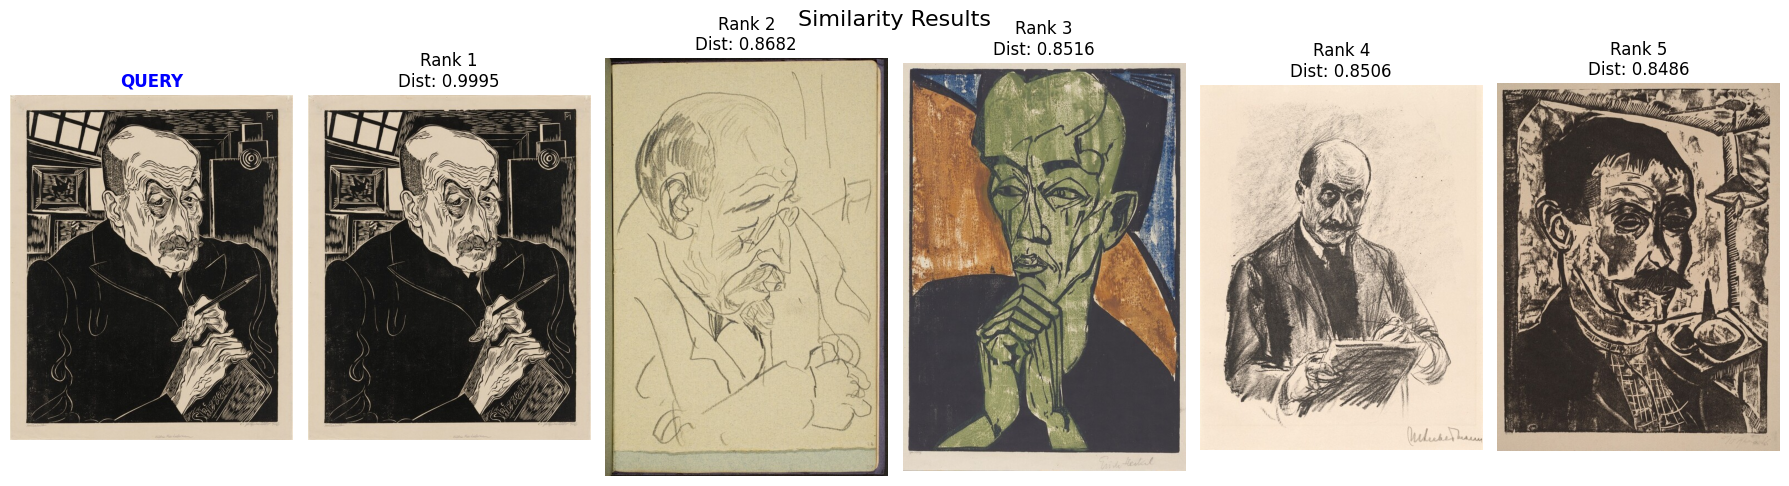

In [12]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_results(query_path, match_paths, scores, title="Similarity Results"):
    plt.figure(figsize=(18, 5))
    
    # 1. Plot the Query Image
    plt.subplot(1, 6, 1)
    plt.imshow(Image.open(query_path))
    plt.title("QUERY", fontweight='bold', color='blue')
    plt.axis("off")
    
    # 2. Plot the Top 5 Matches
    for i in range(min(5, len(match_paths))):
        plt.subplot(1, 6, i + 2)
        plt.imshow(Image.open(match_paths[i]))
        # We round the score for the title
        plt.title(f"Rank {i+1}\nDist: {scores[i]:.4f}")
        plt.axis("off")
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

# --- EXECUTION BLOCK ---
# We use the 'indices' and 'values' from your previous CLIP output
match_paths = [valid_paths[idx] for idx in indices]
match_scores = [score.item() for score in values]

# Call the function to finally see your portraits!
plot_results(valid_paths[query_idx], match_paths, match_scores)


--- Statistical Outliers Found ---
Outlier 1: portraits\273a82c7-e746-409d-81e0-faab0153816b.jpg (Avg Similarity: 0.3513)
Outlier 2: portraits\acc3d805-1446-4313-8b85-5327c47bb2f4.jpg (Avg Similarity: 0.3884)
Outlier 3: portraits\bab3a5c8-80ef-455d-9689-86d08df8a92c.jpg (Avg Similarity: 0.3933)
Outlier 4: portraits\b61eba44-d6ed-4b1d-9e3a-36c47829c629.jpg (Avg Similarity: 0.3948)
Outlier 5: portraits\10134bcf-8281-4ac8-885c-54588dd068a0.jpg (Avg Similarity: 0.4021)


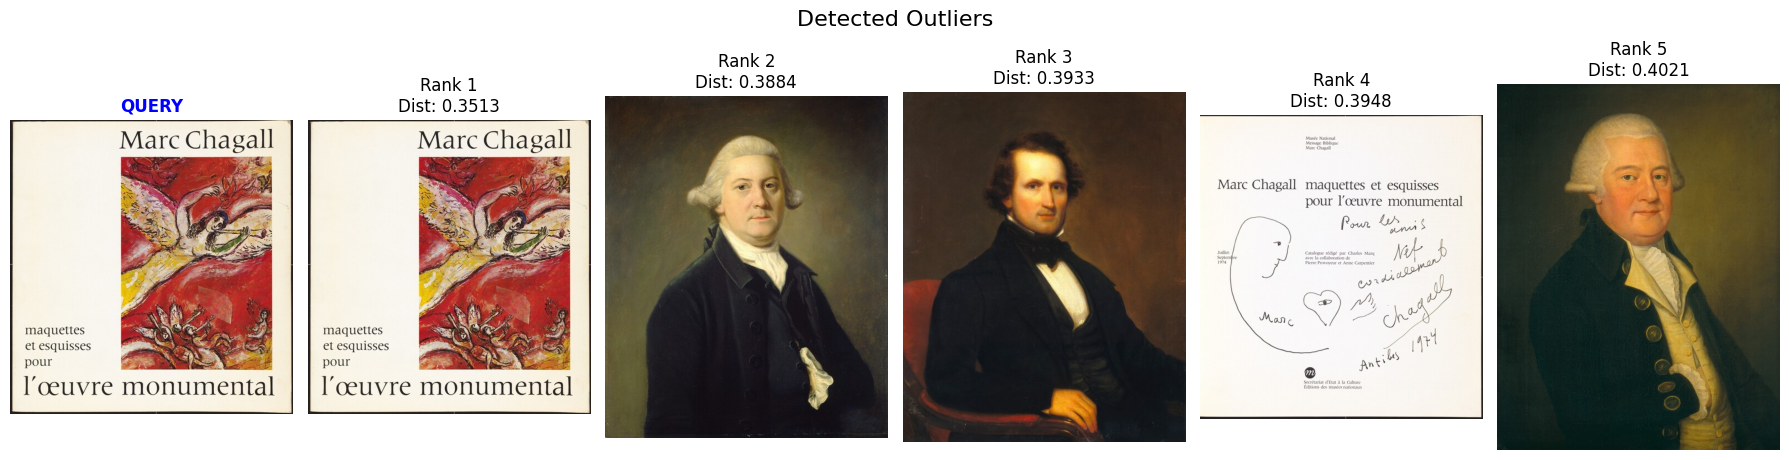

In [13]:
# Calculate the average similarity of each image to every other image in the set
# A high-performance matrix multiplication on your A5500
sim_matrix = torch.matmul(embeddings, embeddings.T)
mean_sim_scores = sim_matrix.mean(dim=1)

# Outliers are the images with the LOWEST mean similarity to the rest of the group
outlier_values, outlier_indices = mean_sim_scores.topk(5, largest=False)

print("\n--- Statistical Outliers Found ---")
outlier_paths = []
for i in range(5):
    idx = outlier_indices[i].item()
    path = valid_paths[idx]
    outlier_paths.append(path)
    print(f"Outlier {i+1}: {path} (Avg Similarity: {outlier_values[i].item():.4f})")

# Visualize them using the plot_results function we defined earlier
plot_results(outlier_paths[0], outlier_paths, outlier_values.tolist(), title="Detected Outliers")

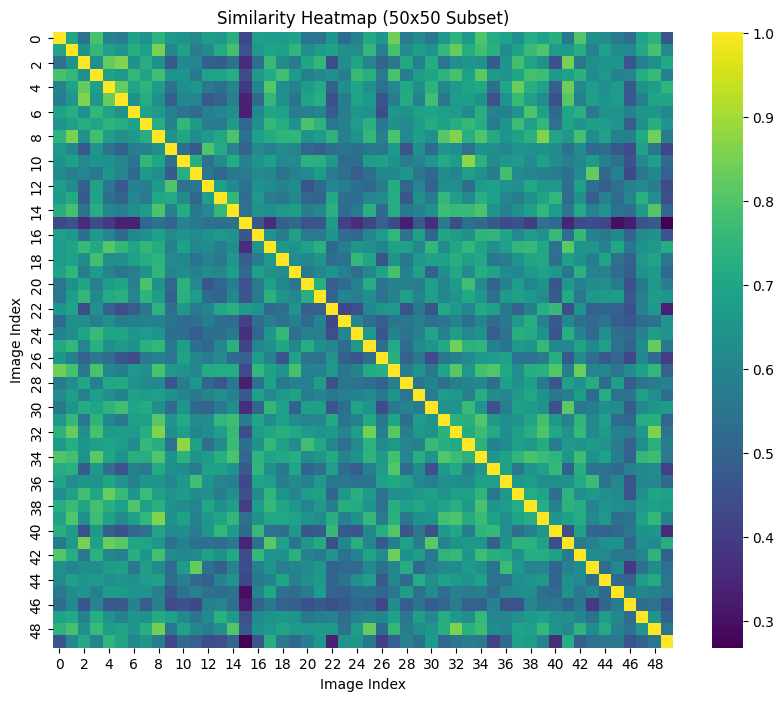

Heatmap generated. Brighter areas indicate high structural/style similarity.


In [14]:
import seaborn as sns
import numpy as np

# 1. Compute the full 1000x1000 similarity matrix on the GPU
# Using the RTX A5500's Tensor cores for high-speed multiplication
full_sim_matrix = (embeddings @ embeddings.T).cpu().numpy()

# 2. Plot a heatmap of a 50x50 subset to visualize clusters
plt.figure(figsize=(10, 8))
sns.heatmap(full_sim_matrix[:50, :50], cmap='viridis')
plt.title("Similarity Heatmap (50x50 Subset)")
plt.xlabel("Image Index")
plt.ylabel("Image Index")
plt.show()

print("Heatmap generated. Brighter areas indicate high structural/style similarity.")

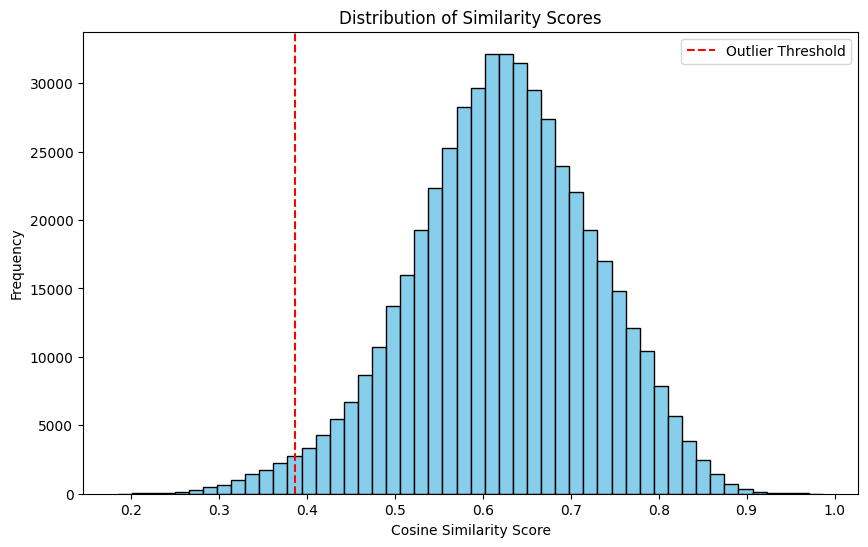

In [15]:
# Flatten the matrix and remove self-similarity (the diagonal of 1.0s)
flat_sims = full_sim_matrix[np.triu_indices(len(full_sim_matrix), k=1)]

plt.figure(figsize=(10, 6))
plt.hist(flat_sims, bins=50, color='skyblue', edgecolor='black')
plt.axvline(x=outlier_values.mean().item(), color='red', linestyle='--', label='Outlier Threshold')
plt.title("Distribution of Similarity Scores")
plt.xlabel("Cosine Similarity Score")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [16]:
# Create a summary of Top 5 and Bottom 5 (Outliers)
results_summary = []

# Add Top Matches for the Query
for i in range(5):
    results_summary.append({
        "Type": "Top Match",
        "Path": valid_paths[indices[i]],
        "Score": values[i].item()
    })

# Add Outliers
for i in range(5):
    results_summary.append({
        "Type": "Outlier",
        "Path": valid_paths[outlier_indices[i]],
        "Score": outlier_values[i].item()
    })

df_results = pd.DataFrame(results_summary)
df_results.to_csv("ArtExtract_Task2_Results.csv", index=False)
print("Final results table saved to ArtExtract_Task2_Results.csv")

Final results table saved to ArtExtract_Task2_Results.csv
